In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from functools import partial
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import numpy as np
import sklearn

from sklearn.datasets import fetch_openml
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_tweedie_deviance,
)

In [3]:
%config InlineBackend.figure_formats = ['svg']

In [4]:
from sklearn.datasets import fetch_openml


def load_mtpl2(n_samples=None):
    """Fetch the French Motor Third-Party Liability Claims dataset.

    Parameters
    ----------
    n_samples: int, default=None
      number of samples to select (for faster run time). Full dataset has
      678013 samples.
    """
    # freMTPL2freq dataset from https://www.openml.org/d/41214
    df_freq = fetch_openml(data_id=41214, as_frame=True).data
    df_freq["IDpol"] = df_freq["IDpol"].astype(int)
    df_freq.set_index("IDpol", inplace=True)
    print(df_freq["ClaimNb"].value_counts())

    # freMTPL2sev dataset from https://www.openml.org/d/41215
    df_sev = fetch_openml(data_id=41215, as_frame=True).data

    # sum ClaimAmount over identical IDs
    df_sev = df_sev.groupby("IDpol").sum()

    df = df_freq.join(df_sev, how="left")
    df["ClaimAmount"] = df["ClaimAmount"].fillna(0)

    # unquote string fields
    for column_name in df.columns[df.dtypes.values == object]:
        df[column_name] = df[column_name].str.strip("'")
    return df.iloc[:n_samples]

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    KBinsDiscretizer,
    OneHotEncoder,
    StandardScaler,
)

df = load_mtpl2()  # .head(10000)


# Correct for unreasonable observations (that might be data error)
# and a few exceptionally large claim amounts
df["ClaimNb"] = df["ClaimNb"].clip(upper=4)
df["Exposure"] = df["Exposure"].clip(upper=1)
df["ClaimAmount"] = df["ClaimAmount"].clip(upper=30000)
# If the claim amount is 0, then we do not count it as a claim. The loss function
# used by the severity model needs strictly positive claim amounts. This way
# frequency and severity are more consistent with each other.
df.loc[(df["ClaimAmount"] == 0) & (df["ClaimNb"] >= 1), "ClaimNb"] = 0

log_scale_transformer = make_pipeline(FunctionTransformer(func=np.log), StandardScaler())

column_trans = ColumnTransformer(
    [
        (
            "binned_numeric",
            KBinsDiscretizer(n_bins=5, random_state=0),
            ["VehAge", "DrivAge"],
        ),
        (
            "onehot_categorical",
            OneHotEncoder(drop="first"),
            ["VehBrand", "VehPower", "VehGas", "Region", "Area", "BonusMalus"],
        ),
        # ("passthrough_numeric", "passthrough", ["BonusMalus"]),
        ("log_scaled_numeric", log_scale_transformer, ["Density"]),
    ],
    remainder="drop",
)
X = column_trans.fit_transform(df)

# Insurances companies are interested in modeling the Pure Premium, that is
# the expected total claim amount per unit of exposure for each policyholder
# in their portfolio:
df["PurePremium"] = df["ClaimAmount"] / df["Exposure"]

# This can be indirectly approximated by a 2-step modeling: the product of the
# Frequency times the average claim amount per claim:
df["Frequency"] = df["ClaimNb"] / df["Exposure"]
df["AvgClaimAmount"] = df["ClaimAmount"] / np.fmax(df["ClaimNb"], 1)

with pd.option_context("display.max_columns", 15):
    print(df[df.ClaimAmount > 0].head())

ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
11         3
5          2
6          1
8          1
16         1
9          1
Name: count, dtype: int64
       ClaimNb  Exposure Area  VehPower  VehAge  DrivAge  BonusMalus VehBrand  \
IDpol                                                                           
139          1      0.75    F         7       1       61          50      B12   
190          1      0.14    B        12       5       50          60      B12   
414          1      0.14    E         4       0       36          85      B12   
424          2      0.62    F        10       0       51         100      B12   
463          1      0.31    A         5       0       45          50      B12   

        VehGas  Density Region  ClaimAmount   PurePremium  Frequency  \
IDpol                                                                  
139    Regular    27000    R11       303.00    404.000000   1.333333   
190     Diesel       56    R25      198

In [6]:
from sklearn.linear_model import PoissonRegressor
from sklearn.model_selection import train_test_split

df_train, df_test, X_train, X_test = train_test_split(df, X, random_state=0)

In [7]:
from sklearn.linear_model import TweedieRegressor

glm_pure_premium = TweedieRegressor(power=1.9, alpha=0.1, solver="newton-cholesky")
glm_pure_premium.fit(X_train, df_train["PurePremium"], sample_weight=df_train["Exposure"])

TweedieRegressor(alpha=0.1, power=1.9, solver='newton-cholesky')

In [8]:
glm_freq = PoissonRegressor(alpha=1e-4, solver="newton-cholesky")
glm_freq.fit(X_train, df_train["Frequency"], sample_weight=df_train["Exposure"])
df_train["PREDICTION_FREQ"] = glm_freq.predict(X_train)
df_test["PREDICTION_FREQ"] = glm_freq.predict(X_test)

In [9]:
df_train["PREDICTION"] = glm_pure_premium.predict(X_train)
df_test["PREDICTION"] = glm_pure_premium.predict(X_test)

In [10]:
df_train = pl.from_pandas(df_train)
df_test = pl.from_pandas(df_test)

In [11]:
df_train.head()

ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmount,PurePremium,Frequency,AvgClaimAmount,PREDICTION_FREQ,PREDICTION
i64,f64,cat,i64,i64,i64,i64,cat,str,i64,cat,f64,f64,f64,f64,f64,f64
0,1.0,"""D""",7,17,49,51,"""B5""","""Regular""",1329,"""R11""",0.0,0.0,0.0,0.0,0.054063,102.925357
0,0.08,"""E""",10,6,46,50,"""B3""","""Diesel""",2498,"""R72""",0.0,0.0,0.0,0.0,0.099441,179.37452
0,0.61,"""E""",6,7,26,72,"""B2""","""Diesel""",2620,"""R72""",0.0,0.0,0.0,0.0,0.112089,224.769894
0,0.55,"""D""",4,0,32,50,"""B12""","""Regular""",634,"""R91""",0.0,0.0,0.0,0.0,0.036584,106.514367
0,0.12,"""B""",5,6,31,64,"""B1""","""Regular""",84,"""R24""",0.0,0.0,0.0,0.0,0.052505,102.326276


In [ ]:
from actuarial_python_tooling.plots import plot_obs_pred_by_feature_value, plot_simple_lift_plot

# from actuarial_python_tooling.models.poisson import *

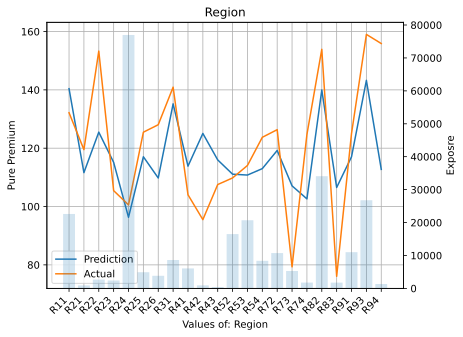

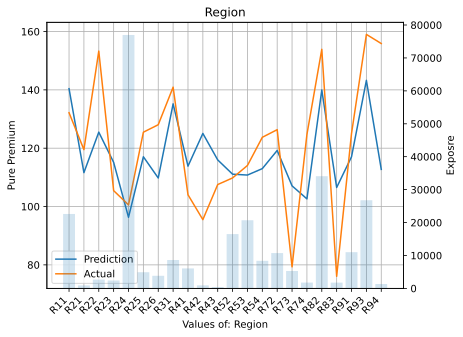

In [13]:
plot_obs_pred_by_feature_value(
    df_train, feature_col="Region", prediction_col="PREDICTION", target_col="PurePremium", weights_col="Exposure"
)

In [83]:
# plot_simple_lift_plot(df_train, prediction_col="PREDICTION", target_col="PurePremium", weights_col="Exposure", weighted_mean=True)

### Simple Lift Plot Frequency Gamma Scikit-learn

2024-11-15 23:08:54.319 | DEBUG    | actuarial_python_tooling.plots:_prepare_simple_lift_plot_data:28 - Labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'PLUS_ONE']
2024-11-15 23:08:54.320 | DEBUG    | actuarial_python_tooling.plots:_prepare_simple_lift_plot_data:30 - Breaks: [26856.903447713157, 53713.806895426314, 80570.71034313946, 107427.61379085263, 134284.51723856578, 161141.42068627893, 187998.3241339921, 214855.22758170526, 241712.13102941838, 268569.03447713156]
2024-11-15 23:08:54.365 | DEBUG    | actuarial_python_tooling.plots:plot_simple_lift_plot:79 - shape: (10, 7)
┌─────────────┬───────────┬───────────────┬───────────────┬──────────────┬───────────────┬─────────┐
│ CUT_WEIGHTS ┆ Frequency ┆ PREDICTION_FR ┆ SEGMENT_NAMES ┆ Exposure     ┆ SUMMED_WEIGHT ┆ NUM_OBS │
│ ---         ┆ ---       ┆ EQ            ┆ ---           ┆ ---          ┆ S             ┆ ---     │
│ cat         ┆ f64       ┆ ---           ┆ str           ┆ f64          ┆ ---           ┆ u32     │


<Axes: xlabel='Prediction segments', ylabel='Pure Premium'>

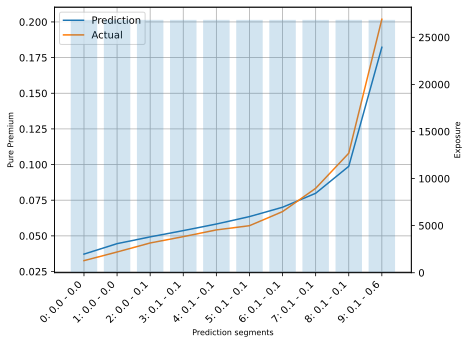

In [84]:
plot_simple_lift_plot(
    df_train, prediction_col="PREDICTION_FREQ", target_col="Frequency", weights_col="Exposure", weighted_mean=True
)

# JAX

In [17]:
jax.config.update("jax_enable_x64", True)

In [18]:
X_train = X_train.astype(np.float32)

In [19]:
init_beta = np.random.random((117, 1)).astype(np.float32)

In [20]:
X_train_j, y_train_j, exposure_j, init_beta_j = jax.device_put(
    (
        X_train.toarray().astype(np.float64),
        df_train["Frequency"].to_numpy().astype(np.float64),
        df_train["Exposure"].to_numpy().astype(np.float64),
        init_beta.astype(np.float64),
    )
)

In [21]:
X_train_j = jnp.c_[X_train_j, jnp.ones(X_train.shape[0])]

In [22]:
df_train.select("Frequency", "PREDICTION_FREQ_2", "Exposure").with_columns(
    pl.col("Frequency") * pl.col("Exposure"), pl.col("PREDICTION_FREQ_2") * pl.col("Exposure")
).sum()

ColumnNotFoundError: PREDICTION_FREQ_2

### Simple Lift Plot Frequency Gamma Jax

2024-08-24 22:32:44.706 | DEBUG    | actuarial_python_tooling.plots:_prepare_simple_lift_plot_data:25 - Labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'PLUS_ONE']
2024-08-24 22:32:44.707 | DEBUG    | actuarial_python_tooling.plots:_prepare_simple_lift_plot_data:27 - Breaks: [388.78717486338803, 777.5743497267761, 1166.3615245901642, 1555.1486994535521, 1943.93587431694, 2332.7230491803284, 2721.5102240437163, 3110.2973989071043, 3499.084573770492, 3887.87174863388]


shape: (10, 7)
┌─────────────┬───────────┬────────────────┬───────────────┬────────────┬────────────────┬─────────┐
│ CUT_WEIGHTS ┆ Frequency ┆ PREDICTION_FRE ┆ SEGMENT_NAMES ┆ Exposure   ┆ SUMMED_WEIGHTS ┆ NUM_OBS │
│ ---         ┆ ---       ┆ Q_2            ┆ ---           ┆ ---        ┆ ---            ┆ ---     │
│ cat         ┆ f64       ┆ ---            ┆ str           ┆ f64        ┆ f64            ┆ u32     │
│             ┆           ┆ f64            ┆               ┆            ┆                ┆         │
╞═════════════╪═══════════╪════════════════╪═══════════════╪════════════╪════════════════╪═════════╡
│ 0           ┆ 0.036078  ┆ 0.021089       ┆ 0: 0.0 - 0.0  ┆ 388.047432 ┆ 388.047432     ┆ 971     │
│ 1           ┆ 0.020543  ┆ 0.033083       ┆ 1: 0.0 - 0.0  ┆ 389.430984 ┆ 777.478415     ┆ 728     │
│ 2           ┆ 0.046309  ┆ 0.038104       ┆ 2: 0.0 - 0.0  ┆ 388.693716 ┆ 1166.172131    ┆ 657     │
│ 3           ┆ 0.046286  ┆ 0.04248        ┆ 3: 0.0 - 0.0  ┆ 388.885464 ┆ 15

<Axes: xlabel='Prediction segments', ylabel='Pure Premium'>

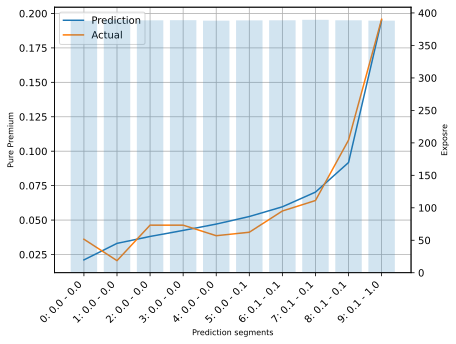

In [ ]:
df_train = df_train.with_columns(
    pl.Series(
        name="PREDICTION_FREQ_2",
        values=np.asarray(pred_optax2).reshape(
            pred_jaxopt.shape[0],
        ),
    )
)
plot_simple_lift_plot(
    df_train, prediction_col="PREDICTION_FREQ_2", target_col="Frequency", weights_col="Exposure", weighted_mean=True
)

# Severity

In [85]:
from sklearn.linear_model import GammaRegressor

sev_train = df_train.filter(pl.col("ClaimAmount") > 0)
sev_test = df_test.filter(pl.col("ClaimAmount") > 0)

mask_train = df_train.to_pandas()["ClaimAmount"] > 0
mask_test = df_test.to_pandas()["ClaimAmount"] > 0

glm_sev = GammaRegressor(alpha=20.0, solver="lbfgs", tol=0.00001)

glm_sev.fit(
    X_train[mask_train.values],
    sev_train["AvgClaimAmount"].to_pandas(),
    sample_weight=sev_train["ClaimNb"].to_pandas(),
)

GammaRegressor(alpha=20.0, tol=1e-05)

In [86]:
sev_train = sev_train.with_columns(PREDICTION_SEV=glm_sev.predict(X_train[mask_train.values]))

In [87]:
import seaborn as sns

<Axes: xlabel='AvgClaimAmount', ylabel='Count'>

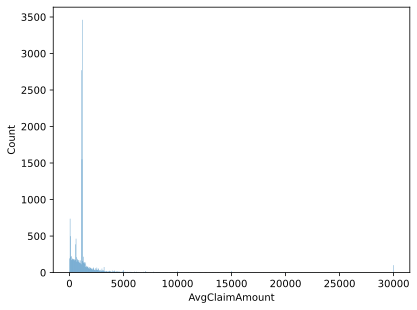

In [88]:
sns.histplot(sev_train, x="AvgClaimAmount")

2024-11-15 23:09:05.870 | DEBUG    | actuarial_python_tooling.plots:_prepare_simple_lift_plot_data:28 - Labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'PLUS_ONE']
2024-11-15 23:09:05.871 | DEBUG    | actuarial_python_tooling.plots:_prepare_simple_lift_plot_data:30 - Breaks: [1293.7608183995808, 2587.5216367991616, 3881.2824551987424, 5175.043273598323, 6468.804091997904, 7762.564910397485, 9056.325728797066, 10350.086547196646, 11643.847365596226, 12937.608183995808]
2024-11-15 23:09:05.879 | DEBUG    | actuarial_python_tooling.plots:plot_simple_lift_plot:79 - shape: (10, 7)
┌─────────────┬───────────────┬──────────────┬──────────────┬─────────────┬──────────────┬─────────┐
│ CUT_WEIGHTS ┆ AvgClaimAmoun ┆ PREDICTION_S ┆ SEGMENT_NAME ┆ Exposure    ┆ SUMMED_WEIGH ┆ NUM_OBS │
│ ---         ┆ t             ┆ EV           ┆ S            ┆ ---         ┆ TS           ┆ ---     │
│ cat         ┆ ---           ┆ ---          ┆ ---          ┆ f64         ┆ ---          ┆ u32     │
│ 

<Axes: xlabel='Prediction segments', ylabel='Pure Premium'>

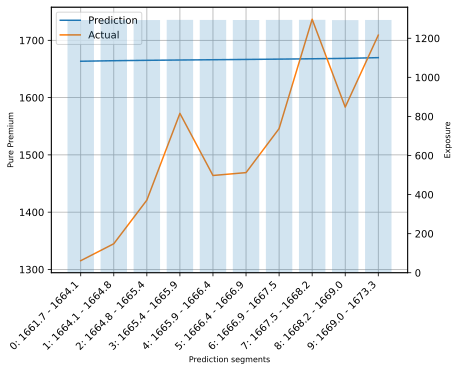

In [89]:
plot_simple_lift_plot(
    sev_train, prediction_col="PREDICTION_SEV", target_col="AvgClaimAmount", weights_col="Exposure", weighted_mean=True
)

In [90]:
sev_train.select("PREDICTION_SEV", "AvgClaimAmount").mean()

PREDICTION_SEV,AvgClaimAmount
f64,f64
1666.632456,1649.185612
